# 1. Base Setup

## 1.1 Install packages

In [1]:
!pip install kagglehub

## 1.2 Load all needed imports

In [52]:
from pathlib import Path

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import matplotlib.pyplot as plt

from dateutil.relativedelta import relativedelta

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, log_loss, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, GridSearchCV

from scipy.stats import randint


# 2. Load the data

In [53]:
def load_cashflow_data(csv_name: str = "dataset.csv") -> pd.DataFrame:
    # 1) Look for local file first: ../raw_data/dataset.csv
    base_dir = Path.cwd().parent          # one level up from notebook
    raw_data_dir = base_dir / "raw_data"
    raw_data_dir.mkdir(parents=True, exist_ok=True)
    local_path = raw_data_dir / csv_name

    if local_path.is_file():
        print(f"Loading local file: {local_path}")
        return pd.read_csv(local_path)

    # 2) If not found, download from Kaggle once via kagglehub
    print("Local file not found, downloading from Kaggle via kagglehub...")
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "pradumn203/payment-date-prediction-for-invoices-dataset",
        "dataset.csv",  # main CSV name on Kaggle
    )

    # Save for future offline use
    df.to_csv(local_path, index=False)
    print(f"Saved local copy to {local_path}")

    return df

df = load_cashflow_data()

Loading local file: /home/saiyudh/code/EwaltsJ/cf_copilot/raw_data/dataset.csv


# 3. EDA

## 3.1 General Informatoin

In [54]:
df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1.930438e+09,2020-01-26,20200125,20200126,20200210.0,USD,RV,1.0,NaN,54273.28,20200126.0,NAH4,1.930438e+09,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1.929646e+09,2019-07-22,20190722,20190722,20190811.0,USD,RV,1.0,NaN,79656.60,20190722.0,NAD1,1.929646e+09,0
2,U001,0200792734,MDV/ trust,2019-12-30 00:00:00,2019.0,1.929874e+09,2019-09-14,20190914,20190914,20190929.0,USD,RV,1.0,NaN,2253.86,20190914.0,NAA8,1.929874e+09,0
3,CA02,0140105686,SYSC llc,NaN,2020.0,2.960623e+09,2020-03-30,20200330,20200330,20200410.0,CAD,RV,1.0,NaN,3299.70,20200331.0,CA10,2.960623e+09,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25 00:00:00,2019.0,1.930148e+09,2019-11-13,20191113,20191113,20191128.0,USD,RV,1.0,NaN,33133.29,20191113.0,NAH4,1.930148e+09,0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           50000 non-null  object 
 1   cust_number             50000 non-null  object 
 2   name_customer           50000 non-null  object 
 3   clear_date              40000 non-null  object 
 4   buisness_year           50000 non-null  float64
 5   doc_id                  50000 non-null  float64
 6   posting_date            50000 non-null  object 
 7   document_create_date    50000 non-null  int64  
 8   document_create_date.1  50000 non-null  int64  
 9   due_in_date             50000 non-null  float64
 10  invoice_currency        50000 non-null  object 
 11  document type           50000 non-null  object 
 12  posting_id              50000 non-null  float64
 13  area_business           0 non-null      float64
 14  total_open_amount       50000 non-null

In [56]:
df.shape

(50000, 19)

## 3.2 Non-Null Values

In [39]:
print(df.isnull().sum())
print(df.isnull().mean().round(4) * 100)

business_code                 0
cust_number                   0
name_customer                 0
clear_date                10000
buisness_year                 0
doc_id                        0
posting_date                  0
document_create_date          0
document_create_date.1        0
due_in_date                   0
invoice_currency              0
document type                 0
posting_id                    0
area_business             50000
total_open_amount             0
baseline_create_date          0
cust_payment_terms            0
invoice_id                    6
isOpen                        0
dtype: int64
business_code               0.00
cust_number                 0.00
name_customer               0.00
clear_date                 20.00
buisness_year               0.00
doc_id                      0.00
posting_date                0.00
document_create_date        0.00
document_create_date.1      0.00
due_in_date                 0.00
invoice_currency            0.00
document type   

# 4. Data Cleaning

## 4.1 Drop duplicates and null-values

## 4.2 Clean data

In [ ]:
def data_cleaning(df: pd.DataFrame) -> tuple:
    """Clean raw data and split into model and demo DataFrames.

    Deduplicates rows, parses dates, renames misspelled columns, selects
    relevant columns, and splits into a model_df (paid invoices only)
    and demo_df (all invoices).

    Args:
        df: raw DataFrame from load_cashflow_data().

    Returns:
        A tuple (model_df, demo_df).
    """
    # to remove warning of SettingWithCopyWarning:
    df = df.copy()
    # drop duplicates
    df = df.drop_duplicates()
    df.columns = df.columns.str.strip()

    # convert cust_number to str
    if "cust_number" in df.columns:
        df["cust_number"] = df["cust_number"].astype(str)

    # Drop invalid invoice ids
    df = df.dropna(subset=["invoice_id"]).copy()
    df["invoice_id"] = pd.to_numeric(df["invoice_id"], errors="coerce")
    df = df[df["invoice_id"].notna()]

    # Parse date columns
    df["due_in_date"] = pd.to_datetime(df["due_in_date"], format="%Y%m%d", errors="coerce")
    df["baseline_create_date"] = pd.to_datetime(df["baseline_create_date"], format="%Y%m%d", errors="coerce")
    df["clear_date"] = pd.to_datetime(df["clear_date"], errors="coerce")

    # Cast IDs
    df["doc_id"] = df["doc_id"].astype("int64")

    # Standardize categorical columns
    cat_cols = ["business_code", "invoice_currency", "cust_payment_terms", "name_customer"]
    for c in cat_cols:
        df[c] = df[c].astype(str)

    # Select and rename columns
    df = df[['doc_id','cust_number', 'buisness_year', 'due_in_date', 'invoice_currency',
             'document type', 'total_open_amount', 'baseline_create_date',
             'cust_payment_terms', 'clear_date']]

    df.rename(columns={
        'buisness_year': 'business_year',
        'clear_date': 'invoice_paid',
        'document type': 'document_type',
        'baseline_create_date': 'invoice_sent',
    }, inplace=True)

    # sort values
    df = df.sort_values("invoice_sent").reset_index(drop=True)

    # data conversion
    df["business_year"] = df["business_year"].round().astype("int64")

    # converting cad to usd
    cad_to_usd_by_year = {
        2018 : 0.771,
        2019 : 0.754,
        2020 : 0.745
    }
    def convert_cad_to_usd_amount(row):
        if row['invoice_currency'].strip().upper() == "USD":
            return row["total_open_amount"]
        elif row['invoice_currency'].strip().upper() == "CAD":
            year = int(row['business_year'])
            rate = cad_to_usd_by_year.get(year,0.75)
            return row["total_open_amount"] * rate
        else:
            return row["total_open_amount"]

    df["total_open_amount"] = df.apply(convert_cad_to_usd_amount,axis=1)

    # final check
    model_df = df[df["invoice_paid"].notnull()]

    # Save processed frames
    #base_dir = Path(__file__).resolve().parents[2]
    #raw_data_dir = base_dir / "raw_data"
    #raw_data_dir.mkdir(parents=True, exist_ok=True)

    #model_df.to_csv(raw_data_dir / "model_df.csv", index=False)

    print(f"Saved model_df ({len(model_df)} rows)")
    return model_df

### Sanity checks on updated data cleaning

Test if its actually working

In [62]:
# Before running data_cleaning once
print("Before CAD → USD:", df["total_open_amount"].sum())

# After running data_cleaning
invoices_clean = data_cleaning(df)
print("After CAD → USD:", invoices_clean["total_open_amount"].sum())

# Sanity: sum of CAD‑only rows before/after
cad_mask = invoices_clean["invoice_currency"].str.strip().str.upper() == "CAD"
print("CAD‑only sum:", invoices_clean.loc[cad_mask, "total_open_amount"].sum())


Before CAD → USD: 1616851082.56
Saved model_df (39152 rows)
After CAD → USD: 1212682811.19017
CAD‑only sum: 130004299.03017


In [66]:
invoices = data_cleaning(df)

invoices.business_year.value_counts()


Saved model_df (39152 rows)


business_year
2019    33969
2020     5183
Name: count, dtype: int64

In [64]:
print(df.total_open_amount.sum())
df.head(2)

1616851082.56


,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1.930438e+09,2020-01-26,20200125,20200126,20200210.0,USD,RV,1.0,NaN,54273.28,20200126.0,NAH4,1.930438e+09,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1.929646e+09,2019-07-22,20190722,20190722,20190811.0,USD,RV,1.0,NaN,79656.60,20190722.0,NAD1,1.929646e+09,0


In [65]:
print(invoices.total_open_amount.sum())
invoices.head(2)


1212682811.19017


,doc_id,cust_number,business_year,due_in_date,invoice_currency,document_type,total_open_amount,invoice_sent,cust_payment_terms,invoice_paid
0,1928721098,0200706844,2019,2018-12-29,USD,RV,576.88000,2018-12-14,NAA8,2019-02-19
1,2960521184,0140104249,2019,2018-12-24,CAD,RV,116878.01502,2018-12-14,CA10,2019-01-23


In [47]:
print(invoices.total_open_amount.sum())
invoices.head(2)

1255304025.86


,doc_id,cust_number,business_year,due_in_date,invoice_currency,document_type,total_open_amount,invoice_sent,cust_payment_terms,invoice_paid
0,1928721098,0200706844,2019.0,2018-12-29,USD,RV,576.88,2018-12-14,NAA8,2019-02-19
1,2960521184,0140104249,2019.0,2018-12-24,CAD,RV,155010.63,2018-12-14,CA10,2019-01-23


# 5. Feature engineering

## 5.1 Use sliding window to extend data

### 5.1.1 Engineer more features based on current date

In [67]:
def engineer_features(snapshot, df_full, current_date):
    """Engineer all features for a given reference date."""

    # 1. Invoice age
    snapshot["invoice_age_days"] = (current_date - snapshot["invoice_sent"]).dt.days

    # 2. Days until due date
    snapshot["days_until_due"] = (snapshot["due_in_date"] - current_date).dt.days

    # 3. Invoice month
    snapshot["invoice_month"] = snapshot["invoice_sent"].dt.month

    # 4. Due month
    snapshot["due_month"] = snapshot["due_in_date"].dt.month

    # 5. Days past due
    snapshot["days_past_due"] = (current_date - snapshot["due_in_date"]).dt.days

    # Behaviour specific to one customer. Needs to be calculated on whole DF,
    # since we need historical data for it

    # Get all invoices that are paid before current_date
    historical = df_full[df_full["invoice_paid"] <= current_date].copy()

    # 6. Customer average payment delay
    # Calculate delay for all paid invoices
    historical["delay"] = (historical["invoice_paid"] - historical["due_in_date"]).dt.days.clip(lower=0)
    # Calculate avg delay for each customer
    avg_delay = historical.groupby("cust_number")["delay"].mean().rename("customer_avg_delay")

    # 7. Customer late payment ratio
    # Caluclate boolean field, whether or not an invoice was paid late
    historical["is_late"] = (historical["invoice_paid"] > historical["due_in_date"]).astype(int)
    # calculate ratio of late-payhments per customer
    late_ratio = historical.groupby("cust_number")["is_late"].mean().rename("late_payment_ratio")

    # 8. Number of previous transactions
    before_current = df_full[df_full["invoice_sent"] < current_date]
    prev_counts = before_current.groupby("cust_number").size().rename("prev_transaction_count")

    # 9. Days since last invoice
    last_invoice = (
        before_current.groupby("cust_number")["invoice_sent"]
        .max()
        .rename("last_invoice_date")
    )

    # Merge all customer-level features
    customer_features = pd.concat([avg_delay, late_ratio, prev_counts, last_invoice], axis=1)
    snapshot = snapshot.merge(customer_features, on="cust_number", how="left")

    # 10. Customer risk score
    snapshot["customer_risk_score"] = (
        0.7 * snapshot["late_payment_ratio"].fillna(0)
        + 0.3 * snapshot["customer_avg_delay"].fillna(0)
    )

    # 11. cont. Convert last invoice date to days
    snapshot["days_since_last_invoice"] = (current_date - snapshot["last_invoice_date"]).dt.days
    snapshot.drop(columns=["last_invoice_date"], inplace=True)

    # Fill NaN for new customers
    snapshot["prev_transaction_count"] = snapshot["prev_transaction_count"].fillna(0).astype(int)

    # 13. Open amount
    snapshot["open_amount"] = snapshot["total_open_amount"]

    return snapshot

### 5.1.2 Create more data with sliding window

In [68]:
all_snapshots = []

start_date = invoices["invoice_sent"].min()

# We need to make sure to have 6 weeks at the end of the last sliding window
# to be able to create y_train
end_date = invoices["invoice_paid"].max() - pd.Timedelta(weeks=6)
# Move one week forward after each calculation
stride = pd.Timedelta(weeks=1)

current = start_date
while current <= end_date:
    # All invoices that have been sent out before current and have not been paid
    # yet
    snapshot = invoices[
        (invoices["invoice_sent"] <= current) &
        (invoices["invoice_paid"] > current)
    ].copy()

    # Engineer aditional features for the sliding window
    snapshot = engineer_features(snapshot, invoices, current)

    # Engineer target (in which bucket did the invoice land)
    snapshot["reference_date"] = current
    snapshot["days_to_payment"] = (snapshot["invoice_paid"] - current).dt.days
    snapshot["week_bucket"] = np.ceil(snapshot["days_to_payment"] / 7).astype(int)
    snapshot["week_bucket"] = snapshot["week_bucket"].clip(lower=1)
    snapshot.loc[snapshot["week_bucket"] > 6, "week_bucket"] = 7

    all_snapshots.append(snapshot)
    current += stride

big_df = pd.concat(all_snapshots, ignore_index=True)
print(f"Original rows: {len(invoices)}")
print(f"Augmented rows: {len(big_df)}")
print(big_df["week_bucket"].value_counts().sort_index())

Original rows: 39152
Augmented rows: 98169
week_bucket
1    38825
2    33060
3    10401
4     4009
5     3172
6     2192
7     6510
Name: count, dtype: int64


In [69]:
big_df.head()

,doc_id,cust_number,business_year,due_in_date,invoice_currency,document_type,total_open_amount,invoice_sent,cust_payment_terms,invoice_paid,...,days_past_due,customer_avg_delay,late_payment_ratio,prev_transaction_count,customer_risk_score,days_since_last_invoice,open_amount,reference_date,days_to_payment,week_bucket
0,1928721098,0200706844,2019,2018-12-29,USD,RV,576.88000,2018-12-14,NAA8,2019-02-19,...,-15,NaN,NaN,0,0.0,NaN,576.88000,2018-12-14,67,7
1,2960521184,0140104249,2019,2018-12-24,CAD,RV,116878.01502,2018-12-14,CA10,2019-01-23,...,-10,NaN,NaN,0,0.0,NaN,116878.01502,2018-12-14,40,6
2,1928721098,0200706844,2019,2018-12-29,USD,RV,576.88000,2018-12-14,NAA8,2019-02-19,...,-8,NaN,NaN,1,0.0,7.0,576.88000,2018-12-21,60,7
3,2960521184,0140104249,2019,2018-12-24,CAD,RV,116878.01502,2018-12-14,CA10,2019-01-23,...,-3,NaN,NaN,1,0.0,7.0,116878.01502,2018-12-21,33,5
4,1928721098,0200706844,2019,2018-12-29,USD,RV,576.88000,2018-12-14,NAA8,2019-02-19,...,-1,NaN,NaN,1,0.0,14.0,576.88000,2018-12-28,53,7


# 6. Cleaning and prepocessing the big DF

## 6.1 Quick EDA on the bigger DF

In [70]:
print(big_df.isnull().sum())

doc_id                        0
cust_number                   0
business_year                 0
due_in_date                   0
invoice_currency              0
document_type                 0
total_open_amount             0
invoice_sent                  0
cust_payment_terms            0
invoice_paid                  0
invoice_age_days              0
days_until_due                0
invoice_month                 0
due_month                     0
days_past_due                 0
customer_avg_delay         6603
late_payment_ratio         6603
prev_transaction_count        0
customer_risk_score           0
days_since_last_invoice     236
open_amount                   0
reference_date                0
days_to_payment               0
week_bucket                   0
dtype: int64


In [115]:
print(big_df.isnull().mean().round(4) * 100)

cust_number                0.00
business_year              0.00
due_in_date                0.00
invoice_currency           0.00
document_type              0.00
total_open_amount          0.00
invoice_sent               0.00
cust_payment_terms         0.00
invoice_paid               0.00
invoice_age_days           0.00
days_until_due             0.00
invoice_month              0.00
due_month                  0.00
days_past_due              0.00
customer_avg_delay         6.74
late_payment_ratio         6.74
prev_transaction_count     0.00
customer_risk_score        0.00
days_since_last_invoice    0.24
open_amount                0.00
reference_date             0.00
days_to_payment            0.00
week_bucket                0.00
dtype: float64


## 6.2 Cleaning and preprocessing

In [71]:
def preprocess(df):
    # make sure there are no empty targets
    df = df.dropna(subset=["week_bucket"])

    # Fill NaN for customers with no history
    df["customer_avg_delay"] = df["customer_avg_delay"].fillna(0)
    df["late_payment_ratio"] = df["late_payment_ratio"].fillna(0)
    df["days_since_last_invoice"] = df["days_since_last_invoice"].fillna(-1)  # flag as unknown

    # Define feature columns (exclude identifiers, dates, target, leaky columns)
    drop_cols = [
        "cust_number", "due_in_date", "invoice_sent", "reference_date", "week_bucket", "days_to_payment"
    ]
    feature_cols = [c for c in df.columns if c not in drop_cols]

    X = df[feature_cols]
    y = df["week_bucket"]

    return X, y

# 7. Prepare training

## 7.1 Train-test-split

In [2]:
# Since we are working with time-series, we can't use the random split but need
# to split the data at a certain date

# Make sure data is sorted correctly
big_df = big_df.sort_values("invoice_sent").reset_index(drop=True)

# Use the last ~20% of time as test
cutoff_date = big_df["invoice_sent"].quantile(0.8)

train_df = big_df[big_df["reference_date"] <= cutoff_date]
test_df = big_df[big_df["reference_date"] > cutoff_date]

# Create train and test datasets
X_train, y_train = preprocess(train_df)
X_test, y_test = preprocess(test_df)

NameError: name 'big_df' is not defined

In [ ]:
big_df.columns

Index(['doc_id', 'cust_number', 'business_year', 'due_in_date',
       'invoice_currency', 'document_type', 'total_open_amount',
       'invoice_sent', 'cust_payment_terms', 'invoice_paid',
       'invoice_age_days', 'days_until_due', 'invoice_month', 'due_month',
       'days_past_due', 'customer_avg_delay', 'late_payment_ratio',
       'prev_transaction_count', 'customer_risk_score',
       'days_since_last_invoice', 'open_amount', 'reference_date',
       'days_to_payment', 'week_bucket'],
      dtype='object')

# 8. Base Model

## 8.1 Pipelines

### 8.1.1 Preprocessing pipeline

In [76]:
# Define column groups
numeric_features = [
    "invoice_age_days", "days_until_due", "days_past_due",
    "invoice_month", "due_month",
    "customer_avg_delay", "late_payment_ratio",
    "prev_transaction_count", "customer_risk_score",
    "days_since_last_invoice", "open_amount",
]

categorical_features = [
    "invoice_currency", "document_type", 'cust_payment_terms'
]

# Numeric: just fill NaN
numeric_transformer = SimpleImputer(strategy="median")

# Categorical: fill NaN then encode as integers
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",  # drop anything not listed above
)

preprocessor

ColumnTransformer(transformers=[('num', SimpleImputer(strategy='median'),
                                 ['invoice_age_days', 'days_until_due',
                                  'days_past_due', 'invoice_month', 'due_month',
                                  'customer_avg_delay', 'late_payment_ratio',
                                  'prev_transaction_count',
                                  'customer_risk_score',
                                  'days_since_last_invoice', 'open_amount']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=-1,
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['invoice_currency', 'document_type',
                                  'cust_payment_terms'])])

### 8.1.2 Model pipeline

In [77]:
classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

classifier

RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=300, n_jobs=-1, random_state=42)

### 8.1.3 Full pipeline

In [78]:
base_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", classifier),
])

base_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['invoice_age_days',
                                                   'days_until_due',
                                                   'days_past_due',
                                                   'invoice_month', 'due_month',
                                                   'customer_avg_delay',
                                                   'late_payment_ratio',
                                                   'prev_transaction_count',
                                                   'customer_risk_score',
                                                   'days_since_last_invoice',
                                                   'open_amount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['invoice_currency',
                                                   'document_type',
                                                   'cust_payment_terms'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=8, min_samples_leaf=10,
                                        min_samples_split=20, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

## 8.2 Sai Rodio v1

In [2]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    log_loss,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer,
    balanced_accuracy_score,
)
from sklearn.calibration import calibration_curve

In [3]:
# ============================================================
# STEP 1: LOAD DATA
# ============================================================
import sys
sys.path.append("..")  # adjust if needed

import pandas as pd
from pathlib import Path

raw_data_dir = Path("../raw_data")
invoices = pd.read_csv(raw_data_dir / "model_df.csv")

date_cols = ["invoice_sent", "due_in_date", "invoice_paid"]
for col in date_cols:
    invoices[col] = pd.to_datetime(invoices[col], errors="coerce")

if "cust_number" in invoices.columns:
    invoices["cust_number"] = invoices["cust_number"].astype(str)

print(f"Loaded {len(invoices)} rows")
print(invoices.dtypes)
print(invoices.head(3))

Loaded 39152 rows
doc_id                         int64
cust_number                   object
business_year                  int64
due_in_date           datetime64[ns]
invoice_currency              object
document_type                 object
total_open_amount            float64
invoice_sent          datetime64[ns]
cust_payment_terms            object
invoice_paid          datetime64[ns]
dtype: object
       doc_id cust_number  business_year due_in_date invoice_currency  \
0  1928721098  0200706844           2019  2018-12-29              USD   
1  2960521184  0140104249           2019  2018-12-24              CAD   
2  1991818786  0140103335           2019  2019-01-29              USD   

  document_type  total_open_amount invoice_sent cust_payment_terms  \
0            RV          576.88000   2018-12-14               NAA8   
1            RV       116878.01502   2018-12-14               CA10   
2            RV        13760.55000   2018-12-30               NAVE   

  invoice_paid  
0   201

In [4]:
# ============================================================
# STEP 2: CUSTOMER SEGMENTATION (KMeans on payment behavior)
# ============================================================
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def build_customer_segments(invoices: pd.DataFrame, n_clusters: int = 4) -> pd.DataFrame:
    paid = invoices[invoices["invoice_paid"].notnull()].copy()
    paid["delay"]   = (paid["invoice_paid"] - paid["due_in_date"]).dt.days.clip(lower=0)
    paid["is_late"] = (paid["invoice_paid"] > paid["due_in_date"]).astype(int)

    customer_stats = paid.groupby("cust_number").agg(
        avg_delay       =("delay",            "mean"),
        late_ratio      =("is_late",          "mean"),
        total_invoices  =("doc_id",           "count"),
        avg_open_amount =("total_open_amount","mean"),
    ).reset_index()

    seg_features = ["avg_delay", "late_ratio", "total_invoices", "avg_open_amount"]
    scaler = StandardScaler()
    X_seg  = scaler.fit_transform(customer_stats[seg_features].fillna(0))

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    customer_stats["customer_segment"] = kmeans.fit_predict(X_seg)

    return customer_stats[["cust_number", "customer_segment"]]


customer_segments = build_customer_segments(invoices)
invoices = invoices.merge(customer_segments, on="cust_number", how="left")

print(invoices["customer_segment"].value_counts().sort_index())


customer_segment
0    11402
1    18268
2     8762
3      720
Name: count, dtype: int64


In [5]:
# ============================================================
# STEP 3: FEATURE ENGINEERING + SLIDING WINDOW SNAPSHOTS
# ============================================================

def engineer_features(snapshot: pd.DataFrame, df_full: pd.DataFrame,
                      current_date: pd.Timestamp) -> pd.DataFrame:

    # A) Invoice timing
    snapshot["invoice_age_days"] = (current_date - snapshot["invoice_sent"]).dt.days
    snapshot["days_until_due"]   = (snapshot["due_in_date"] - current_date).dt.days
    snapshot["days_past_due"]    = (current_date - snapshot["due_in_date"]).dt.days
    snapshot["invoice_month"]    = snapshot["invoice_sent"].dt.month
    snapshot["due_month"]        = snapshot["due_in_date"].dt.month
    snapshot["invoice_quarter"]  = snapshot["invoice_sent"].dt.quarter
    snapshot["due_quarter"]      = snapshot["due_in_date"].dt.quarter
    snapshot["invoice_dow"]      = snapshot["invoice_sent"].dt.dayofweek

    # Sin/cos cyclic encoding for month and day-of-week
    snapshot["invoice_month_sin"] = np.sin(2 * np.pi * snapshot["invoice_month"] / 12)
    snapshot["invoice_month_cos"] = np.cos(2 * np.pi * snapshot["invoice_month"] / 12)
    snapshot["due_month_sin"]     = np.sin(2 * np.pi * snapshot["due_month"] / 12)
    snapshot["due_month_cos"]     = np.cos(2 * np.pi * snapshot["due_month"] / 12)
    snapshot["invoice_dow_sin"]   = np.sin(2 * np.pi * snapshot["invoice_dow"] / 7)
    snapshot["invoice_dow_cos"]   = np.cos(2 * np.pi * snapshot["invoice_dow"] / 7)

    # B) Customer behavioral features (history-only, no leakage)
    historical     = df_full[df_full["invoice_paid"] <= current_date].copy()
    before_current = df_full[df_full["invoice_sent"]  < current_date]

    historical["delay"]   = (historical["invoice_paid"] - historical["due_in_date"]).dt.days.clip(lower=0)
    historical["is_late"] = (historical["invoice_paid"] > historical["due_in_date"]).astype(int)

    avg_delay   = historical.groupby("cust_number")["delay"].mean().rename("customer_avg_delay")
    late_ratio  = historical.groupby("cust_number")["is_late"].mean().rename("late_payment_ratio")
    prev_counts = before_current.groupby("cust_number").size().rename("prev_transaction_count")
    last_inv    = before_current.groupby("cust_number")["invoice_sent"].max().rename("last_invoice_date")
    max_delay   = historical.groupby("cust_number")["delay"].max().rename("customer_max_delay")
    delay_std   = historical.groupby("cust_number")["delay"].std().rename("customer_delay_std")

    customer_features = pd.concat(
        [avg_delay, late_ratio, prev_counts, last_inv, max_delay, delay_std], axis=1
    )
    snapshot = snapshot.merge(customer_features, on="cust_number", how="left")

    snapshot["customer_risk_score"]     = (
        0.7 * snapshot["late_payment_ratio"].fillna(0)
        + 0.3 * snapshot["customer_avg_delay"].fillna(0)
    )
    snapshot["days_since_last_invoice"] = (current_date - snapshot["last_invoice_date"]).dt.days
    snapshot.drop(columns=["last_invoice_date"], inplace=True)
    snapshot["prev_transaction_count"]  = snapshot["prev_transaction_count"].fillna(0).astype(int)

    # C) Amount features
    snapshot["open_amount"]         = snapshot["total_open_amount"]
    snapshot["invoice_amount_log"]  = np.log1p(snapshot["total_open_amount"].clip(lower=0))

    return snapshot


# ── Sliding window ──────────────────────────────────────────
all_snapshots = []

start_date = invoices["invoice_sent"].min()
end_date   = invoices["invoice_paid"].max() - pd.Timedelta(weeks=6)
stride     = pd.Timedelta(weeks=1)
current    = start_date

while current <= end_date:
    snapshot = invoices[
        (invoices["invoice_sent"] <= current) &
        (invoices["invoice_paid"] >  current)
    ].copy()

    snapshot = engineer_features(snapshot, invoices, current)

    snapshot["reference_date"]  = current
    snapshot["days_to_payment"] = (snapshot["invoice_paid"] - current).dt.days
    snapshot["week_bucket"]     = np.ceil(snapshot["days_to_payment"] / 7).astype(int)
    snapshot["week_bucket"]     = snapshot["week_bucket"].clip(lower=1)
    snapshot.loc[snapshot["week_bucket"] > 6, "week_bucket"] = 7

    all_snapshots.append(snapshot)
    current += stride

big_df = pd.concat(all_snapshots, ignore_index=True)

print(f"Original rows : {len(invoices)}")
print(f"Augmented rows: {len(big_df)}")
print(big_df["week_bucket"].value_counts().sort_index())


Original rows : 39152
Augmented rows: 98169
week_bucket
1    38825
2    33060
3    10401
4     4009
5     3172
6     2192
7     6510
Name: count, dtype: int64


In [6]:
# ============================================================
# STEP 4: PREPROCESS + TIME-BASED SPLIT
# ============================================================

def preprocess(df: pd.DataFrame):
    df = df.dropna(subset=["week_bucket"]).copy()

    df["customer_avg_delay"]      = df["customer_avg_delay"].fillna(0)
    df["late_payment_ratio"]      = df["late_payment_ratio"].fillna(0)
    df["customer_max_delay"]      = df["customer_max_delay"].fillna(0)
    df["customer_delay_std"]      = df["customer_delay_std"].fillna(0)
    df["days_since_last_invoice"] = df["days_since_last_invoice"].fillna(-1)

    drop_cols = [
        "cust_number", "due_in_date", "invoice_sent", "invoice_paid",
        "reference_date", "week_bucket", "days_to_payment",
        "doc_id", "total_open_amount",
    ]
    feature_cols = [c for c in df.columns if c not in drop_cols]

    return df[feature_cols], df["week_bucket"]


big_df = big_df.sort_values("reference_date").reset_index(drop=True)
cutoff_date = big_df["reference_date"].quantile(0.8)

train_df = big_df[big_df["reference_date"] <= cutoff_date]
test_df  = big_df[big_df["reference_date"] >  cutoff_date]

X_train, y_train = preprocess(train_df)
X_test,  y_test  = preprocess(test_df)

# XGBoost-safe labels (0-indexed)
y_train_xgb = y_train - 1
y_test_xgb  = y_test  - 1

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Classes in y_train: {sorted(y_train.unique())}")


Train: (79725, 28)  |  Test: (18444, 28)
Classes in y_train: [1, 2, 3, 4, 5, 6, 7]


In [7]:
# ============================================================
# STEP 5: FEATURE GROUPS + SKLEARN PREPROCESSOR
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

invoice_time_features = [
    "invoice_age_days", "days_until_due", "days_past_due",
    "invoice_month", "due_month", "invoice_quarter", "due_quarter",
    "invoice_dow",
    # cyclic encodings
    "invoice_month_sin", "invoice_month_cos",
    "due_month_sin", "due_month_cos",
    "invoice_dow_sin", "invoice_dow_cos",
]

customer_behavior_features = [
    "customer_avg_delay", "late_payment_ratio", "prev_transaction_count",
    "customer_risk_score", "customer_max_delay", "customer_delay_std",
    "days_since_last_invoice",
]

financial_features = [
    "open_amount", "invoice_amount_log",
]

categorical_features = [
    "invoice_currency", "document_type", "cust_payment_terms",
    "customer_segment", "business_year",
]

numeric_features = invoice_time_features + customer_behavior_features + financial_features

# Filter to only columns that actually exist
numeric_features     = [c for c in numeric_features     if c in X_train.columns]
categorical_features = [c for c in categorical_features if c in X_train.columns]

print("Numeric features :", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Missing from X_train:",
      [c for c in numeric_features + categorical_features if c not in X_train.columns])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,     numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

all_feature_names = numeric_features + categorical_features


Numeric features : 23
Categorical features: 5
Missing from X_train: []


In [8]:
# ============================================================
# STEP 6: EVALUATION HELPERS
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import (
    log_loss, f1_score, classification_report,
    confusion_matrix, make_scorer, balanced_accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

scoring = {
    "macro_f1"          : make_scorer(f1_score, average="macro",    zero_division=0),
    "weighted_f1"       : make_scorer(f1_score, average="weighted", zero_division=0),
    "balanced_accuracy" : make_scorer(balanced_accuracy_score),
}


def evaluate_model(name, pipeline, X, y, label_offset=0):
    """
    label_offset: set to 1 when pipeline was trained on 0-indexed XGB labels
                  so preds are shifted back to [1..7] for reporting.
    """
    probas = pipeline.predict_proba(X)
    preds  = pipeline.predict(X)
    preds_report = preds + label_offset
    y_report     = y    + label_offset if label_offset else y

    ll    = log_loss(y, probas)
    mf1   = f1_score(y_report, preds_report, average="macro",    zero_division=0)
    wf1   = f1_score(y_report, preds_report, average="weighted", zero_division=0)
    ba    = balanced_accuracy_score(y_report, preds_report)

    print(f"\n{'='*55}")
    print(f"  Model : {name}")
    print(f"  Log Loss          : {ll:.4f}")
    print(f"  Macro F1          : {mf1:.4f}")
    print(f"  Weighted F1       : {wf1:.4f}")
    print(f"  Balanced Accuracy : {ba:.4f}")
    print(classification_report(y_report, preds_report, zero_division=0))
    print(confusion_matrix(y_report, preds_report))

    return {
        "name": name, "probas": probas, "preds": preds,
        "log_loss": ll, "macro_f1": mf1, "weighted_f1": wf1, "balanced_accuracy": ba,
    }


def show_calibration_curves(name, probas, classes, y):
    n = len(classes)
    cols = 4
    rows = -(-n // cols)  # ceiling division
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, bucket in enumerate(classes):
        ax = axes[i]
        y_binary = (y == bucket).astype(int)
        if y_binary.nunique() < 2:
            ax.set_title(f"Bucket {bucket} — no variation")
            ax.axis("off")
            continue
        prob_true, prob_pred = calibration_curve(y_binary, probas[:, i], n_bins=10, strategy="uniform")
        ax.plot(prob_pred, prob_true, marker="o", label="Model")
        ax.plot([0, 1], [0, 1], "k--", label="Perfect")
        ax.set_title(f"{name} — Bucket {bucket}")
        ax.set_xlabel("Predicted prob")
        ax.set_ylabel("Actual fraction")
        ax.legend(fontsize=7)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Calibration Curves — {name}", fontsize=13)
    plt.tight_layout()
    plt.show()


def show_feature_importance(pipeline, feature_names, title="Feature Importances", top_n=20):
    clf = pipeline.named_steps.get("classifier")
    if clf is None or not hasattr(clf, "feature_importances_"):
        print(f"{title}: model has no feature_importances_")
        return
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=True)
    importances.tail(top_n).plot(kind="barh", figsize=(10, 7), title=title, color="steelblue")
    plt.tight_layout()
    plt.show()


def plot_train_vs_val(results_list):
    """Bar chart comparing Train vs Test macro F1 across all models."""
    names, train_f1s, test_f1s = [], [], []

    for r in results_list:
        names.append(r["name"])
        test_f1s.append(r["macro_f1"])

    x = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x, test_f1s, width=0.5, label="Test Macro F1", color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_ylabel("Macro F1")
    ax.set_title("Model Score Comparison — Test Macro F1")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_learning_curve(name, pipeline, X, y, cv=5):
    """Plots train vs cross-val score across training set sizes to detect over/underfitting."""
    from sklearn.model_selection import learning_curve

    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y,
        cv=cv,
        scoring="balanced_accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(9, 5))
    plt.plot(train_sizes, train_mean, "o-", label="Train", color="steelblue")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="steelblue")
    plt.plot(train_sizes, val_mean, "o-", label="Validation", color="tomato")
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="tomato")
    plt.title(f"Learning Curve — {name}")
    plt.xlabel("Training set size")
    plt.ylabel("Balanced Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

all_results = []  # collects every model result dict for the final comparison table



  Model : RandomForest (baseline)
  Log Loss          : 0.9560
  Macro F1          : 0.5422
  Weighted F1       : 0.7342
  Balanced Accuracy : 0.5714
              precision    recall  f1-score   support

           1       0.86      0.85      0.85      8195
           2       0.80      0.68      0.74      6322
           3       0.56      0.45      0.50      1831
           4       0.20      0.68      0.31       612
           5       0.49      0.36      0.42       444
           6       0.38      0.30      0.34       282
           7       0.61      0.67      0.64       758

    accuracy                           0.72     18444
   macro avg       0.56      0.57      0.54     18444
weighted avg       0.76      0.72      0.73     18444

[[6965  623   91  383   10   11  112]
 [ 929 4324  506  425   36   15   87]
 [ 115  364  833  430   42    9   38]
 [  32   32   45  417   45   16   25]
 [  17   11   14  189  160   31   22]
 [  16    2    4  116   18   85   41]
 [  42   21    5  117   

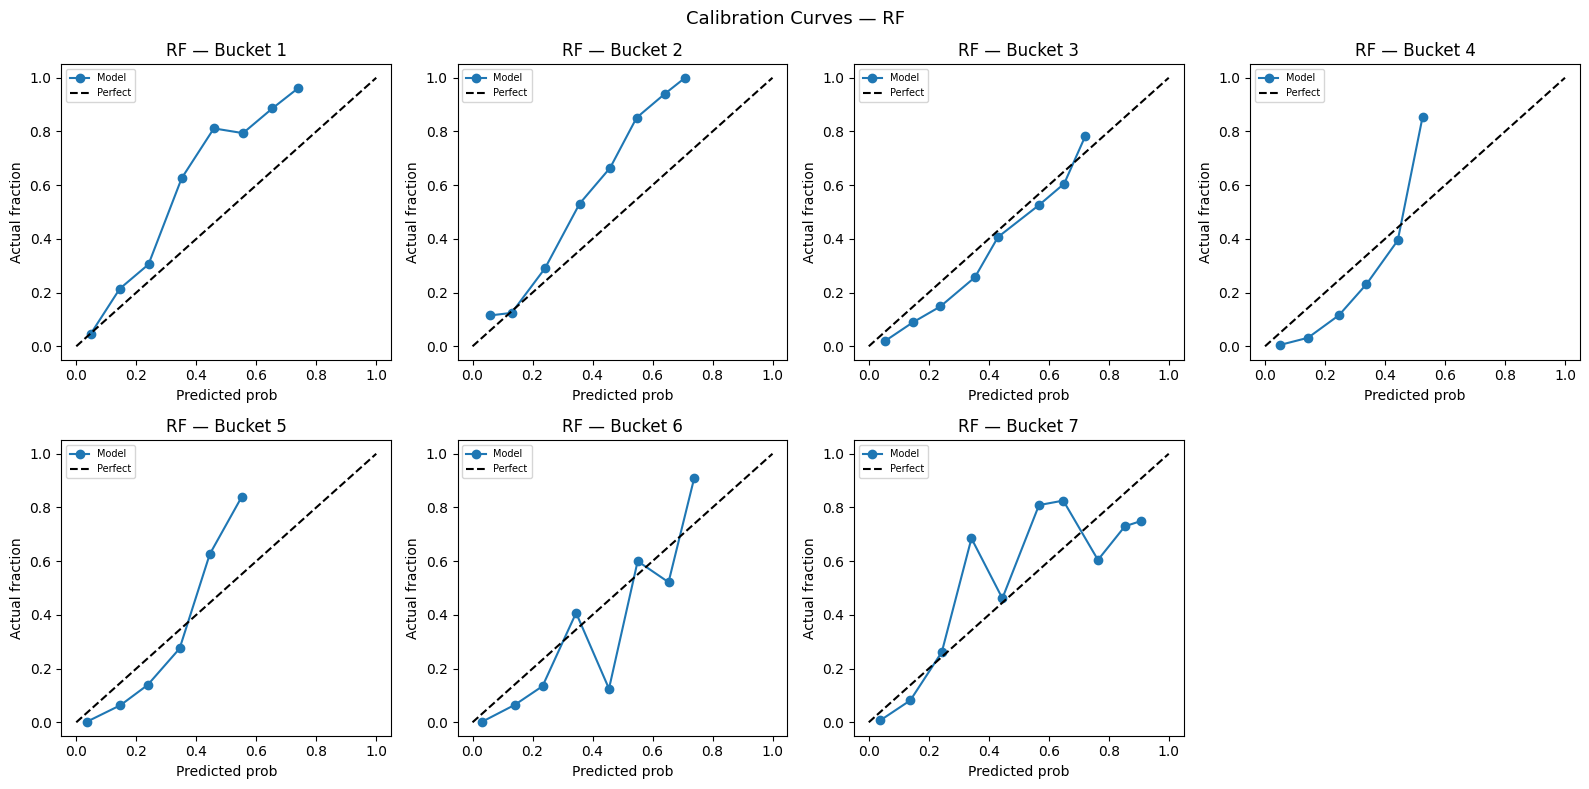

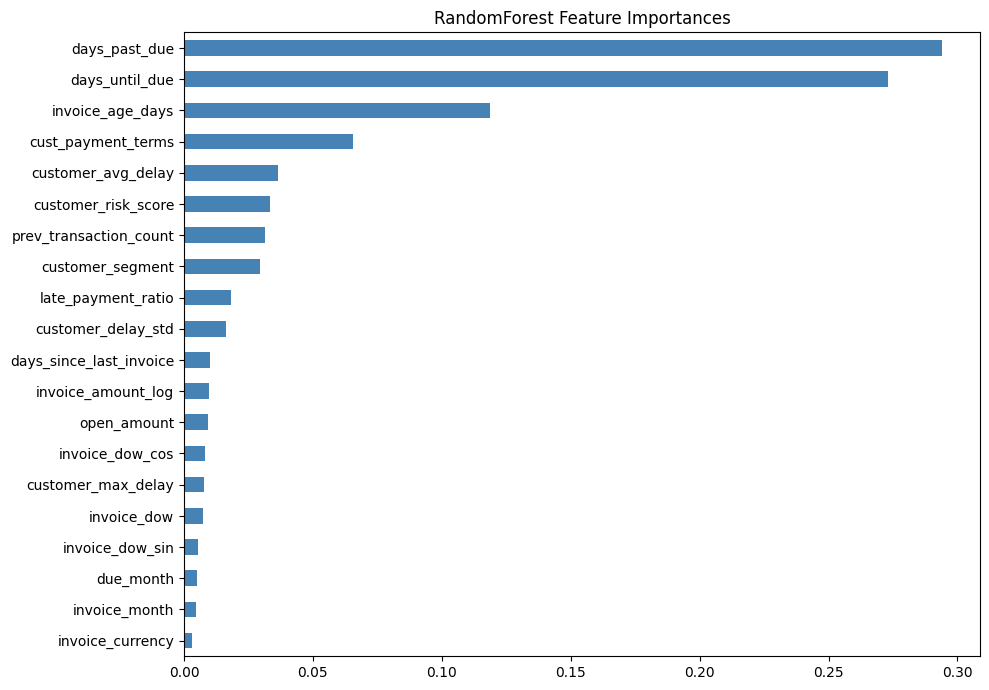

In [9]:
# ============================================================
# STEP 7: BASELINE — RANDOM FOREST
# ============================================================
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)
rf_results = evaluate_model("RandomForest (baseline)", rf_pipeline, X_test, y_test)
all_results.append(rf_results)

show_calibration_curves("RF", rf_results["probas"], rf_pipeline.classes_, y_test)
show_feature_importance(rf_pipeline, all_feature_names, "RandomForest Feature Importances")



  Model : ExtraTrees
  Log Loss          : 1.2346
  Macro F1          : 0.5170
  Weighted F1       : 0.7114
  Balanced Accuracy : 0.5361
              precision    recall  f1-score   support

           1       0.83      0.86      0.85      8195
           2       0.78      0.64      0.71      6322
           3       0.46      0.40      0.43      1831
           4       0.20      0.61      0.30       612
           5       0.43      0.30      0.36       444
           6       0.43      0.28      0.34       282
           7       0.63      0.65      0.64       758

    accuracy                           0.70     18444
   macro avg       0.54      0.54      0.52     18444
weighted avg       0.73      0.70      0.71     18444

[[7083  587  119  292   19   11   84]
 [1130 4057  650  361   28   14   82]
 [ 131  455  735  416   43   11   40]
 [  43   37   69  372   56   12   23]
 [  23   13   27  197  134   30   20]
 [  24    4    6  117   15   80   36]
 [  69   19    5  127   14   30  494]

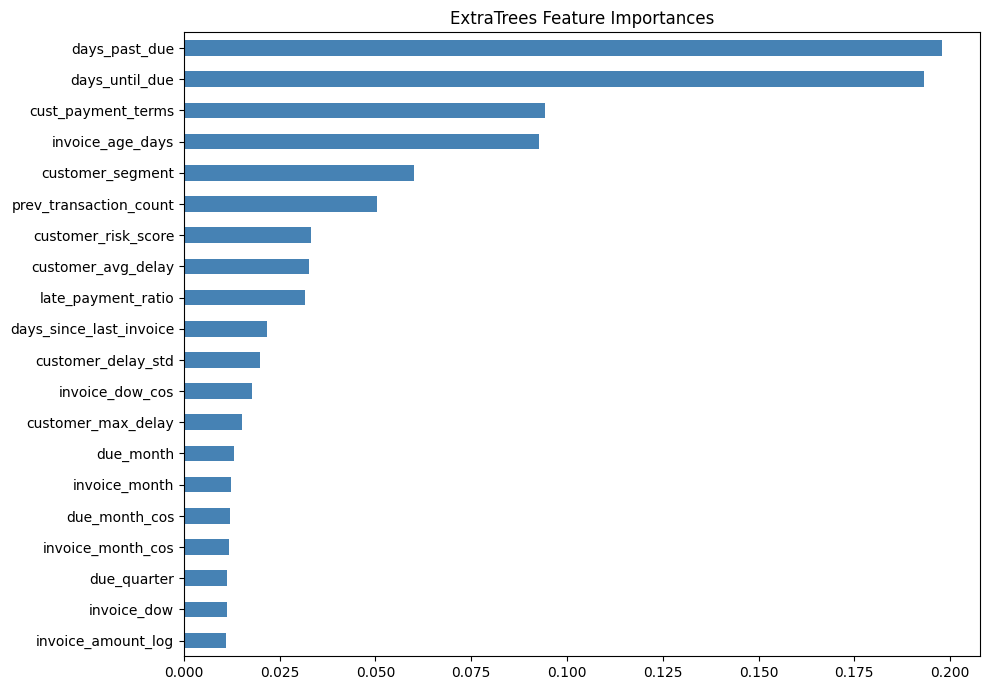

In [16]:
# ============================================================
# STEP 8: EXTRA TREES
# ============================================================
from sklearn.ensemble import ExtraTreesClassifier

et_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", ExtraTreesClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

et_pipeline.fit(X_train, y_train)
et_results = evaluate_model("ExtraTrees", et_pipeline, X_test, y_test)
all_results.append(et_results)

show_feature_importance(et_pipeline, all_feature_names, "ExtraTrees Feature Importances")


In [10]:
# ============================================================
# STEP 9: HISTGRADIENTBOOSTING
# ============================================================
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=500,
        max_depth=5,
        learning_rate=0.05,
        l2_regularization=0.1,
        class_weight="balanced",
        random_state=42,
    )),
])

hgb_pipeline.fit(X_train, y_train)
hgb_results = evaluate_model("HistGradientBoosting", hgb_pipeline, X_test, y_test)
all_results.append(hgb_results)



  Model : HistGradientBoosting
  Log Loss          : 0.8489
  Macro F1          : 0.5529
  Weighted F1       : 0.7321
  Balanced Accuracy : 0.5579
              precision    recall  f1-score   support

           1       0.84      0.85      0.85      8195
           2       0.75      0.71      0.73      6322
           3       0.51      0.50      0.51      1831
           4       0.28      0.53      0.37       612
           5       0.45      0.35      0.39       444
           6       0.44      0.28      0.34       282
           7       0.68      0.69      0.69       758

    accuracy                           0.73     18444
   macro avg       0.57      0.56      0.55     18444
weighted avg       0.74      0.73      0.73     18444

[[6935  936  101  123   20    6   74]
 [ 938 4517  603  151   34   10   69]
 [ 172  439  919  229   35    8   29]
 [  74   53   91  323   43   11   17]
 [  28   32   47  129  154   33   21]
 [  19   10    8   97   33   78   37]
 [  47   23   22   85   27 

In [13]:
# ============================================================
# STEP 10: XGBOOST + RANDOMIZEDSEARCHCV
# NOTE: XGBoost needs 0-indexed labels → use y_train_xgb / y_test_xgb
# Predictions are shifted back by +1 inside evaluate_model via label_offset
# ============================================================
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_param_dist = {
    "classifier__n_estimators"     : [200, 400, 600, 800],
    "classifier__max_depth"        : [3, 4, 5, 6],
    "classifier__learning_rate"    : [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample"        : [0.6, 0.7, 0.8, 1.0],
    "classifier__colsample_bytree" : [0.6, 0.7, 0.8, 1.0],
    "classifier__min_child_weight" : [1, 3, 5, 10],
    "classifier__reg_alpha"        : [0, 0.01, 0.1, 1],
    "classifier__reg_lambda"       : [1, 1.5, 2, 5],
}

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=42,
        verbosity=0,
    )),
])

xgb_search = RandomizedSearchCV(
    estimator           = xgb_pipeline,
    param_distributions = xgb_param_dist,
    n_iter              = 12,
    scoring             = scoring,
    refit               = "macro_f1",
    cv                  = 5,
    n_jobs              = 12,
    verbose             = 1,
    random_state        = 42,
)
xgb_search.fit(X_train, y_train_xgb)  # ← 0-indexed labels

print("Best XGB params:", xgb_search.best_params_)
print("Best macro F1  :", xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_

# label_offset=1 shifts preds [0..6] back to [1..7] for reporting
xgb_results = evaluate_model("XGBoost (tuned)", best_xgb, X_test, y_test_xgb, label_offset=1)
all_results.append(xgb_results)

show_calibration_curves("XGB", xgb_results["probas"], best_xgb.classes_, y_test_xgb)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


KeyboardInterrupt: 

In [ ]:
# ============================================================
# STEP 11: LIGHTGBM + RANDOMIZEDSEARCHCV
# LightGBM handles [1..7] labels natively — no offset needed
# ============================================================
from lightgbm import LGBMClassifier

lgbm_param_dist = {
    "classifier__n_estimators"      : [200, 400, 600, 800],
    "classifier__max_depth"         : [3, 4, 5, 6, -1],
    "classifier__learning_rate"     : [0.01, 0.05, 0.1, 0.2],
    "classifier__num_leaves"        : [15, 31, 63, 127],
    "classifier__subsample"         : [0.6, 0.7, 0.8, 1.0],
    "classifier__colsample_bytree"  : [0.6, 0.7, 0.8, 1.0],
    "classifier__reg_alpha"         : [0, 0.01, 0.1, 1],
    "classifier__reg_lambda"        : [0, 0.01, 0.1, 1],
    "classifier__min_child_samples" : [5, 10, 20, 50],
}

lgbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )),
])

lgbm_search = RandomizedSearchCV(
    estimator           = lgbm_pipeline,
    param_distributions = lgbm_param_dist,
    n_iter              = 60,
    scoring             = scoring,
    refit               = "macro_f1",
    cv                  = 5,
    n_jobs              = -1,
    verbose             = 1,
    random_state        = 42,
)
lgbm_search.fit(X_train, y_train)

print("Best LGBM params:", lgbm_search.best_params_)
print("Best macro F1   :", lgbm_search.best_score_)

best_lgbm = lgbm_search.best_estimator_
lgbm_results = evaluate_model("LightGBM (tuned)", best_lgbm, X_test, y_test)
all_results.append(lgbm_results)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


In [11]:
# ============================================================
# STEP 12: ADABOOST
# ============================================================
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", AdaBoostClassifier(
        estimator     = DecisionTreeClassifier(max_depth=3),
        n_estimators  = 200,
        learning_rate = 0.1,
        random_state  = 42,
        algorithm     = "SAMME",  # required in sklearn >= 1.4
    )),
])

ada_pipeline.fit(X_train, y_train)
ada_results = evaluate_model("AdaBoost", ada_pipeline, X_test, y_test)
all_results.append(ada_results)


/home/saiyudh/.pyenv/versions/cf_copilot/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



  Model : AdaBoost
  Log Loss          : 1.8967
  Macro F1          : 0.5222
  Weighted F1       : 0.7156
  Balanced Accuracy : 0.5101
              precision    recall  f1-score   support

           1       0.83      0.85      0.84      8195
           2       0.70      0.78      0.74      6322
           3       0.50      0.28      0.36      1831
           4       0.37      0.34      0.36       612
           5       0.43      0.35      0.39       444
           6       0.49      0.23      0.32       282
           7       0.59      0.73      0.65       758

    accuracy                           0.73     18444
   macro avg       0.56      0.51      0.52     18444
weighted avg       0.71      0.73      0.72     18444

[[7005  994   86   20    3    2   85]
 [1032 4904  229   59   10    5   83]
 [ 194  901  516  134   41    1   44]
 [  75   99  113  209   61    4   51]
 [  43   37   54   75  157   28   50]
 [  33    7   10   43   54   66   69]
 [  63   37   16   21   40   28  553]]


In [12]:
# ============================================================
# STEP 13: BAGGING VARIANTS
# Pre-transform once so we pass numpy arrays directly.
# ============================================================
from sklearn.ensemble import BaggingClassifier

X_train_t = preprocessor.fit_transform(X_train, y_train)
X_test_t  = preprocessor.transform(X_test)

bagging_variants = {
    "Bagging (bootstrap rows)": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=300, max_samples=0.8, max_features=1.0,
        bootstrap=True, oob_score=True, n_jobs=-1, random_state=42,
    ),
    "Pasting (no replacement)": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=300, max_samples=0.8, max_features=1.0,
        bootstrap=False, n_jobs=-1, random_state=42,
    ),
    "Random Subspaces (feat only)": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=300, max_samples=1.0, max_features=0.6,
        bootstrap=False, bootstrap_features=True, n_jobs=-1, random_state=42,
    ),
    "Random Patches (rows+feats)": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=300, max_samples=0.8, max_features=0.6,
        bootstrap=True, bootstrap_features=True, n_jobs=-1, random_state=42,
    ),
}

bagging_results = []
for name, clf in bagging_variants.items():
    clf.fit(X_train_t, y_train)
    preds  = clf.predict(X_test_t)
    probas = clf.predict_proba(X_test_t)
    mf1 = f1_score(y_test, preds, average="macro", zero_division=0)
    ll  = log_loss(y_test, probas)
    ba  = balanced_accuracy_score(y_test, preds)

    oob = f"{clf.oob_score_:.4f}" if hasattr(clf, "oob_score_") and clf.oob_score else "N/A"
    print(f"{name:40s}  Macro F1: {mf1:.4f}  Log Loss: {ll:.4f}  Balanced Acc: {ba:.4f}  OOB: {oob}")

    bagging_results.append({
        "name": name, "probas": probas, "preds": preds,
        "log_loss": ll, "macro_f1": mf1, "weighted_f1":
            f1_score(y_test, preds, average="weighted", zero_division=0),
        "balanced_accuracy": ba,
    })

all_results.extend(bagging_results)


Bagging (bootstrap rows)                  Macro F1: 0.5566  Log Loss: 0.7064  Balanced Acc: 0.5495  OOB: 0.7593
Pasting (no replacement)                  Macro F1: 0.5543  Log Loss: 0.7291  Balanced Acc: 0.5484  OOB: N/A
Random Subspaces (feat only)              Macro F1: 0.5539  Log Loss: 0.7222  Balanced Acc: 0.5393  OOB: N/A
Random Patches (rows+feats)               Macro F1: 0.5556  Log Loss: 0.7212  Balanced Acc: 0.5415  OOB: N/A


In [17]:
# ============================================================
# STEP 14: SOFT VOTING CLASSIFIER
# RF, ET, LGBM all use [1..7] labels — safe to combine directly.
# XGBoost is excluded here because it uses 0-indexed labels.
# To include XGB, you'd need a label-remapping wrapper.
# ============================================================
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("rf",   rf_pipeline),
        ("et",   et_pipeline),
        #("lgbm", best_lgbm),
        ("hgb",  hgb_pipeline),
    ],
    voting="soft",
    n_jobs=-1,
)

voting_clf.fit(X_train, y_train)
voting_results = evaluate_model("Soft Voting (RF+ET+LGBM+HGB)", voting_clf, X_test, y_test)
all_results.append(voting_results)



  Model : Soft Voting (RF+ET+LGBM+HGB)
  Log Loss          : 0.9184
  Macro F1          : 0.5612
  Weighted F1       : 0.7411
  Balanced Accuracy : 0.5685
              precision    recall  f1-score   support

           1       0.84      0.87      0.86      8195
           2       0.78      0.71      0.74      6322
           3       0.55      0.49      0.52      1831
           4       0.27      0.58      0.37       612
           5       0.47      0.35      0.40       444
           6       0.47      0.30      0.37       282
           7       0.66      0.68      0.67       758

    accuracy                           0.74     18444
   macro avg       0.58      0.57      0.56     18444
weighted avg       0.75      0.74      0.74     18444

[[7138  740   87  139   11    6   74]
 [1022 4469  531  186   31   10   73]
 [ 167  421  900  265   32    9   37]
 [  67   45   71  352   46   12   19]
 [  27   25   35  155  154   25   23]
 [  19    9    7   96   29   86   36]
 [  45   21   12  1

In [18]:
# ============================================================
# STEP 15: STACKING CLASSIFIER
# Meta-learner: Logistic Regression on out-of-fold predictions.
# XGBoost excluded for same label-indexing reason as voting.
# ============================================================
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_clf = StackingClassifier(
    estimators=[
        ("rf",   rf_pipeline),
        ("et",   et_pipeline),
        #("lgbm", best_lgbm),
        ("hgb",  hgb_pipeline),
    ],
    final_estimator=LogisticRegression(
        max_iter=1000, C=1.0, class_weight="balanced"
    ),
    passthrough=False,
    cv=5,
    n_jobs=-1,
)

stacking_clf.fit(X_train, y_train)
stacking_results = evaluate_model("Stacking (RF+ET+LGBM+HGB → LR)", stacking_clf, X_test, y_test)
all_results.append(stacking_results)



  Model : Stacking (RF+ET+LGBM+HGB → LR)
  Log Loss          : 0.8476
  Macro F1          : 0.5450
  Weighted F1       : 0.7320
  Balanced Accuracy : 0.5735
              precision    recall  f1-score   support

           1       0.85      0.86      0.85      8195
           2       0.80      0.67      0.73      6322
           3       0.50      0.51      0.51      1831
           4       0.24      0.62      0.35       612
           5       0.41      0.37      0.39       444
           6       0.36      0.33      0.35       282
           7       0.63      0.65      0.64       758

    accuracy                           0.72     18444
   macro avg       0.54      0.57      0.55     18444
weighted avg       0.75      0.72      0.73     18444

[[7049  643  123  251   27   10   92]
 [ 998 4218  686  273   55   11   81]
 [ 147  336  934  316   52   10   36]
 [  54   27   68  381   39   21   22]
 [  19   11   27  157  163   41   26]
 [  13    3    7   99   32   94   34]
 [  36   20    8 

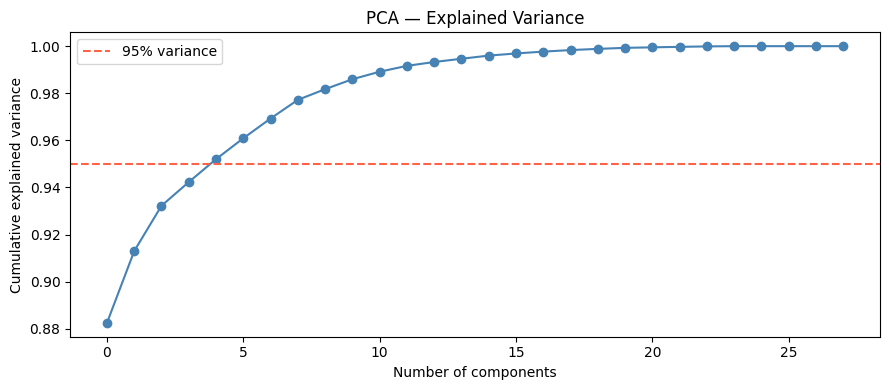

Components needed to explain 95% variance: 5
Original feature count: 28

  Model : RF + PCA
  Log Loss          : 1.3735
  Macro F1          : 0.2904
  Weighted F1       : 0.4368
  Balanced Accuracy : 0.3455
              precision    recall  f1-score   support

           1       0.56      0.73      0.63      8195
           2       0.53      0.22      0.31      6322
           3       0.27      0.15      0.19      1831
           4       0.15      0.65      0.25       612
           5       0.24      0.13      0.16       444
           6       0.12      0.17      0.14       282
           7       0.32      0.37      0.34       758

    accuracy                           0.46     18444
   macro avg       0.31      0.35      0.29     18444
weighted avg       0.48      0.46      0.44     18444

[[5966 1053  253  536   17   58  312]
 [3727 1414  436  549   26   31  139]
 [ 723  190  271  520   46   23   58]
 [  79   10   28  400   31   29   35]
 [  32    6   15  281   56   29   25]
 [  1

In [19]:
# ============================================================
# STEP 16: PCA — OPTIONAL DIMENSIONALITY REDUCTION
# Run on pre-transformed numeric data.
# Check how many components explain 95% variance.
# ============================================================
from sklearn.decomposition import PCA

X_train_num = preprocessor.fit_transform(X_train)

pca = PCA().fit(X_train_num)
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(9, 4))
plt.plot(cumvar, marker="o", color="steelblue")
plt.axhline(0.95, color="tomato", linestyle="--", label="95% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumvar >= 0.95) + 1)
print(f"Components needed to explain 95% variance: {n_components_95}")
print(f"Original feature count: {X_train_num.shape[1]}")

# Optional: build a PCA pipeline and test it
pca_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=n_components_95)),
    ("classifier", RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight="balanced",
        random_state=42, n_jobs=-1,
    )),
])
pca_pipeline.fit(X_train, y_train)
pca_results = evaluate_model("RF + PCA", pca_pipeline, X_test, y_test)
all_results.append(pca_results)


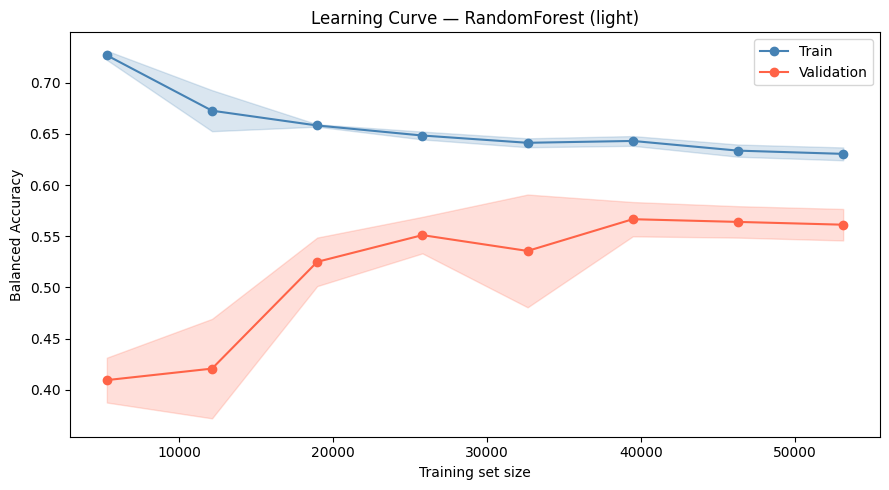

NameError: name 'best_lgbm' is not defined

In [21]:
# ============================================================
# STEP 17: LEARNING CURVES
# Run only on models that showed a large train-test gap.
# Use a lighter estimator to keep runtime manageable.
# ============================================================

# Light RF for fast learning curve
light_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100, max_depth=6,
        class_weight="balanced", random_state=42, n_jobs=-1,
    )),
])

plot_learning_curve("RandomForest (light)", light_rf, X_train, y_train, cv=3)

# If LightGBM ran fast, check it too
plot_learning_curve("LightGBM (tuned)", best_lgbm, X_train, y_train, cv=3)


                         Model  Macro F1  Weighted F1  Balanced Accuracy  Log Loss
  Soft Voting (RF+ET+LGBM+HGB)    0.5617       0.7387             0.5695    0.8269
  Soft Voting (RF+ET+LGBM+HGB)    0.5612       0.7411             0.5685    0.9184
      Bagging (bootstrap rows)    0.5566       0.7472             0.5495    0.7064
   Random Patches (rows+feats)    0.5556       0.7464             0.5415    0.7212
      Pasting (no replacement)    0.5543       0.7471             0.5484    0.7291
  Random Subspaces (feat only)    0.5539       0.7440             0.5393    0.7222
          HistGradientBoosting    0.5529       0.7321             0.5579    0.8489
Stacking (RF+ET+LGBM+HGB → LR)    0.5450       0.7320             0.5735    0.8476
       RandomForest (baseline)    0.5422       0.7342             0.5714    0.9560
                      AdaBoost    0.5222       0.7156             0.5101    1.8967
                    ExtraTrees    0.5170       0.7114             0.5361    1.2346
    

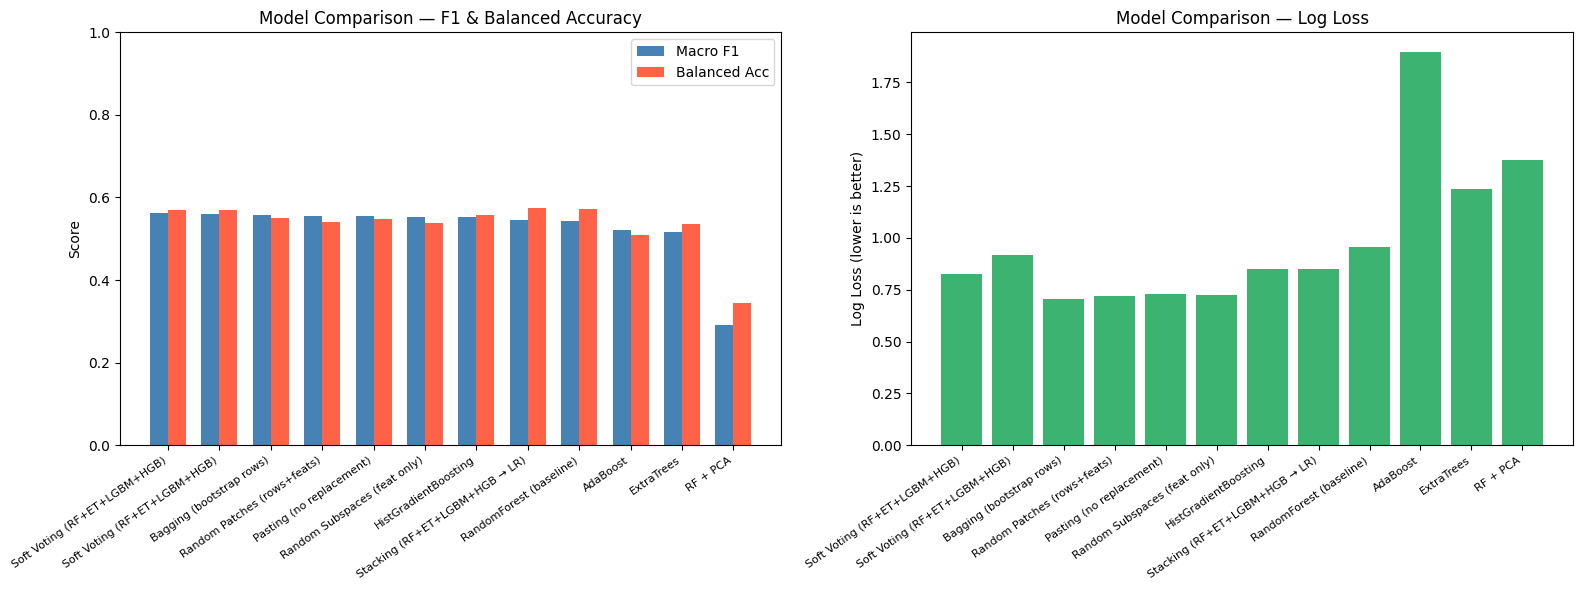

In [22]:
# ============================================================
# STEP 18: FINAL COMPARISON TABLE + BAR CHART
# ============================================================

summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model"            : r["name"],
        "Macro F1"         : round(r["macro_f1"],         4),
        "Weighted F1"      : round(r["weighted_f1"],      4),
        "Balanced Accuracy": round(r["balanced_accuracy"],4),
        "Log Loss"         : round(r["log_loss"],         4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Macro F1", ascending=False)
print(summary_df.to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models    = summary_df["Model"]
x         = np.arange(len(models))
bar_width = 0.35

# Left: F1 scores
axes[0].bar(x - bar_width/2, summary_df["Macro F1"],         bar_width, label="Macro F1",    color="steelblue")
axes[0].bar(x + bar_width/2, summary_df["Balanced Accuracy"],bar_width, label="Balanced Acc",color="tomato")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=35, ha="right", fontsize=8)
axes[0].set_ylabel("Score")
axes[0].set_title("Model Comparison — F1 & Balanced Accuracy")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Right: Log Loss (lower is better)
axes[1].bar(x, summary_df["Log Loss"], color="mediumseagreen")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("Log Loss (lower is better)")
axes[1].set_title("Model Comparison — Log Loss")

plt.tight_layout()
plt.show()


## 8.2 Train the model

In [ ]:
base_pipeline.fit(X_train, y_train)

base_probas = base_pipeline.predict_proba(X_test)
base_preds = base_pipeline.predict(X_test)

# 9. Evaluation of the model

In [ ]:
def evaluate_model(probas, preds):
    print(f"Log loss: {log_loss(y_test, probas):.4f}")
    print(classification_report(y_test, preds))
    print(confusion_matrix(y_test, preds))
    return None

In [ ]:
def show_calibration_curves(probas, pipeline):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, bucket in enumerate(pipeline.classes_):
        ax = axes.flat[i]
        y_binary = (y_test == bucket).astype(int)
        prob_true, prob_pred = calibration_curve(y_binary, probas[:, i], n_bins=10)
        ax.plot(prob_pred, prob_true, marker="o")
        ax.plot([0, 1], [0, 1], "k--")
        ax.set_title(f"Bucket {bucket}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [ ]:
evaluate_model(base_probas, base_preds)

Log loss: 0.9554
              precision    recall  f1-score   support

           1       0.86      0.83      0.85      9647
           2       0.81      0.68      0.74      7578
           3       0.54      0.46      0.50      2170
           4       0.21      0.62      0.31       783
           5       0.49      0.38      0.43       554
           6       0.30      0.39      0.34       311
           7       0.45      0.65      0.54       768

    accuracy                           0.71     21811
   macro avg       0.52      0.57      0.53     21811
weighted avg       0.75      0.71      0.73     21811

[[8015  695  182  469   17   13  256]
 [1075 5135  608  533   48   21  158]
 [ 121  445 1000  445   47   38   74]
 [  36   47   52  488   64   52   44]
 [  14   18   14  186  211   83   28]
 [  12    2    5  101   27  121   43]
 [  35   21    5  114   16   75  502]]


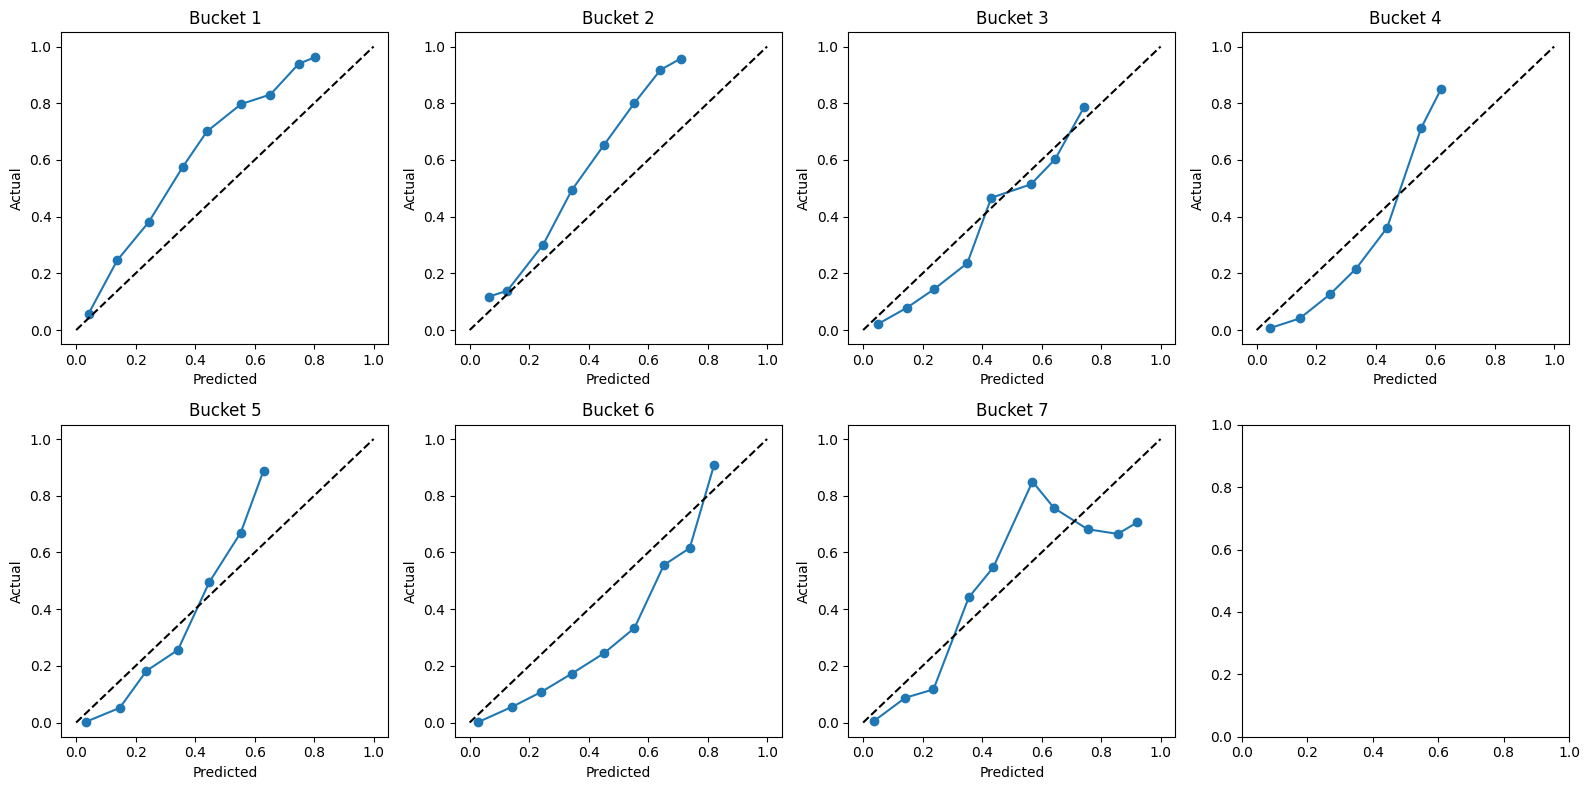

In [ ]:
show_calibration_curves(base_probas, base_pipeline)

## 9.2 Simulate how the model would have performed at any point in time

In [129]:
def simulate_past_performance(pipeline):
    reference_dates = big_df["reference_date"].sort_values().unique()
    cutoffs = np.percentile(reference_dates.astype(int), [40, 50, 60, 70, 80])
    cutoffs = pd.to_datetime(cutoffs)

    scores = []
    for cutoff in cutoffs:
        train_df = big_df[big_df["reference_date"] <= cutoff]
        test_df = big_df[
            (big_df["reference_date"] > cutoff) &
            (big_df["reference_date"] <= cutoff + pd.Timedelta(weeks=6))
        ]

        if len(test_df) == 0:
            continue

        X_train, y_train = preprocess(train_df)
        X_test, y_test = preprocess(test_df)

        pipeline.fit(X_train, y_train)
        probas = pipeline.predict_proba(X_test)
        score = log_loss(y_test, probas, labels=pipeline.classes_)
        scores.append(score)
        print(f"Cutoff {cutoff.date()} -> log_loss: {score:.4f}")

    print(f"\nAverage: {np.mean(scores):.4f} (std: {np.std(scores):.4f})")

In [130]:
simulate_past_performance(base_pipeline)

Cutoff 2019-06-25 -> log_loss: 0.9492
Cutoff 2019-08-12 -> log_loss: 0.9767
Cutoff 2019-09-29 -> log_loss: 1.0559
Cutoff 2019-11-17 -> log_loss: 0.9216
Cutoff 2020-01-04 -> log_loss: 0.8857

Average: 0.9578 (std: 0.0576)


# 10. Tune the model

In [ ]:
cutoff_date = big_df["reference_date"].quantile(0.8)
test_fold = np.where(big_df["reference_date"] <= cutoff_date, -1, 0)
ps = PredefinedSplit(test_fold)

## 10.1 GridSearchCV

In [ ]:
# WARNING THIS CREATES 648 FOLDS SO IT TAKES A LONG TIME TO RUN LOCALLY AND MIGHT
# CRASH YOUR COMPUTER

# cutoff_date = big_df["reference_date"].quantile(0.8)
# test_fold = np.where(big_df["reference_date"] <= cutoff_date, -1, 0)
# ps = PredefinedSplit(test_fold)

# X, y = preprocess(big_df)

# param_grid = {
#     "classifier__n_estimators": [200, 300, 500],
#     "classifier__max_depth": [5, 8, 12, 15],
#     "classifier__min_samples_split": [10, 20, 30],
#     "classifier__min_samples_leaf": [5, 10, 20],
#     "classifier__max_features": ["sqrt", "log2", 0.3],
#     "classifier__class_weight": ["balanced", "balanced_subsample"],
# }

# grid_search = GridSearchCV(
#     base_pipeline,
#     param_grid,
#     cv=ps,
#     scoring="neg_log_loss",
#     n_jobs=-1,
#     verbose=1,
# )

# grid_search.fit(X, y)
# print(f"Best log_loss: {-grid_search.best_score_:.4f}")
# print(f"Best params: {grid_search.best_params_}")

# best_pipeline = grid_search.best_estimator_

Fitting 1 folds for each of 648 candidates, totalling 648 fits


## 10.2 RandomSearchCV

In [ ]:
param_distributions = {
    "classifier__n_estimators": [100, 200, 300, 400, 500],
    "classifier__max_depth": [5, 8, 10, 12, 15, 20, None],
    "classifier__min_samples_split": randint(5, 40),
    "classifier__min_samples_leaf": randint(3, 30),
    "classifier__max_features": ["sqrt", "log2", 0.2, 0.3, 0.5],
    "classifier__class_weight": ["balanced", "balanced_subsample"],
}

random_search = RandomizedSearchCV(
    base_pipeline,
    param_distributions,
    n_iter=50,
    cv=ps,
    scoring="neg_log_loss",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

random_search.fit(X, y)
print(f"Best log_loss: {-random_search.best_score_:.4f}")
print(f"Best params: {random_search.best_params_}")
